# Lab 6 Task: Ecommerce Customers

This notebook applies the Lab 6 linear regression workflow to the **Ecommerce Customers** dataset.

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load The Dataset Into a DataFrame

In [2]:
file_path = '../data/Ecommerce Customers'
df = pd.read_csv(file_path)
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


## 3. Explore The Data

In [3]:
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())

Shape: (500, 8)

Columns:
['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Email,500,500,mstephenson@fernandez.com,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,500,500,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Avatar,500,138,SlateBlue,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Avg. Session Length,500.0,NaN,NaN,NaN,33.053194,0.992563,29.532429,32.341822,33.082008,33.711985,36.139662
Time on App,500.0,NaN,NaN,NaN,12.052488,0.994216,8.508152,11.388153,11.983231,12.75385,15.126994
Time on Website,500.0,NaN,NaN,NaN,37.060445,1.010489,33.913847,36.349257,37.069367,37.716432,40.005182
Length of Membership,500.0,NaN,NaN,NaN,3.533462,0.999278,0.269901,2.93045,3.533975,4.126502,6.922689
Yearly Amount Spent,500.0,NaN,NaN,NaN,499.314038,79.314782,256.670582,445.038277,498.887875,549.313828,765.518462


In [6]:
df.isna().sum().sort_values(ascending=False)

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

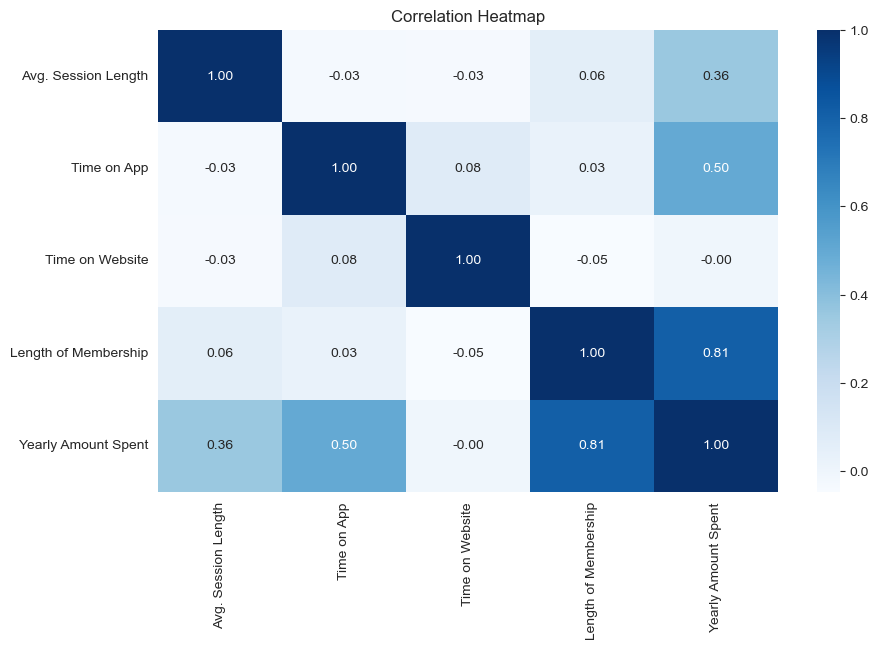

In [7]:
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 4. Perform Basic Data Cleaning

In [8]:
print('Duplicate rows before cleaning:', df.duplicated().sum())

df = df.drop_duplicates().copy()

print('Duplicate rows after cleaning:', df.duplicated().sum())
print('Missing values after cleaning:')
print(df.isna().sum())

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0
Missing values after cleaning:
Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64


## 5. Apply Feature Engineering

In [9]:
# Extract a simple categorical feature from the email address.
df['Email_Domain'] = df['Email'].str.split('@').str[-1]

# Create a numeric feature that captures how long the address text is.
df['Address_Length'] = df['Address'].str.len()

df[['Email', 'Email_Domain', 'Address_Length']].head()

,Email,Email_Domain,Address_Length
0,mstephenson@fernandez.com,fernandez.com,43
1,hduke@hotmail.com,hotmail.com,45
2,pallen@yahoo.com,yahoo.com,57
3,riverarebecca@gmail.com,gmail.com,47
4,mstephens@davidson-herman.com,davidson-herman.com,54


## 6. Prepare The Data For Modeling

In [10]:
target = 'Yearly Amount Spent'

feature_columns = [
    'Avg. Session Length',
    'Time on App',
    'Time on Website',
    'Length of Membership',
    'Address_Length',
    'Email_Domain',
]

X = df[feature_columns]
y = df[target]

numeric_features = [
    'Avg. Session Length',
    'Time on App',
    'Time on Website',
    'Length of Membership',
    'Address_Length',
]
categorical_features = ['Email_Domain']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=101
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (300, 6)
X_test shape: (200, 6)


## 7. Train The Model

In [11]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 8. Evaluate Model Performance

In [12]:
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R^2'],
    'Value': [mae, mse, rmse, r2]
})

metrics_df

,Metric,Value
0,MAE,7.912466
1,MSE,97.591723
2,RMSE,9.878852
3,R^2,0.984926


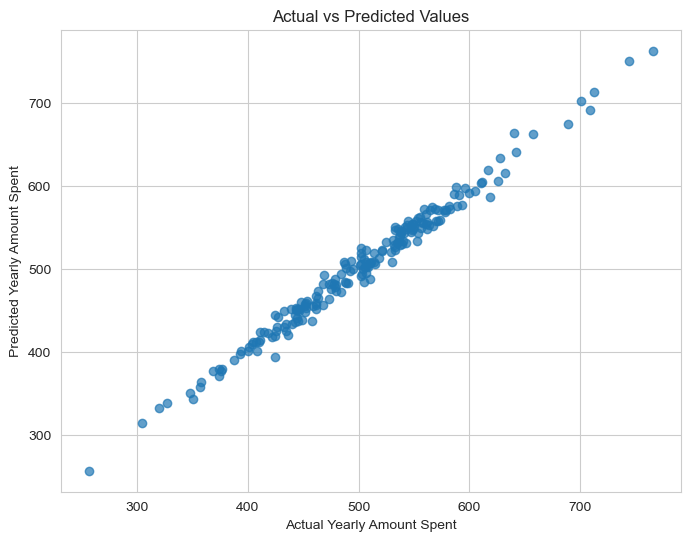

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.7)
plt.xlabel('Actual Yearly Amount Spent')
plt.ylabel('Predicted Yearly Amount Spent')
plt.title('Actual vs Predicted Values')
plt.show()

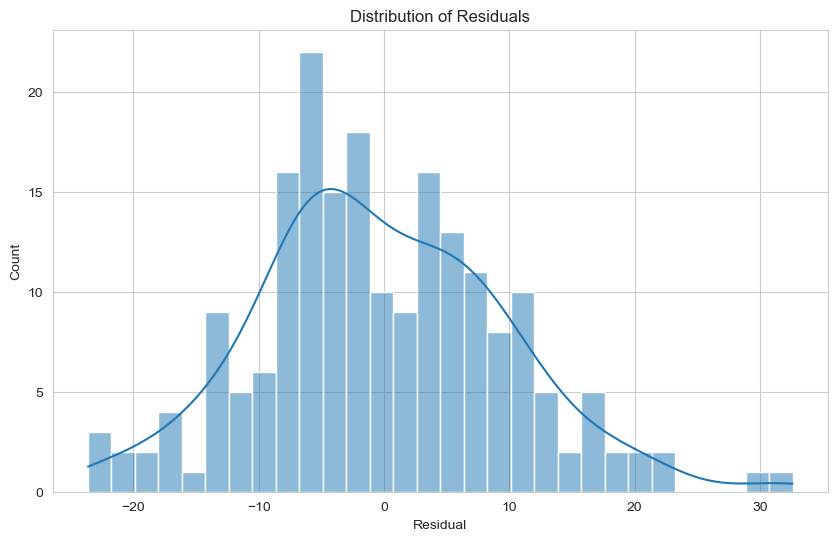

In [14]:
residuals = y_test - predictions

sns.histplot(residuals, bins=30, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.show()

## 9. Conclusion

The **Linear Regression** model was trained using the same modeling approach from the lab.
After preparing the ecommerce dataset and adding a small engineered feature, the model performance was evaluated using **MAE, MSE, RMSE, and R²**.